Chapter 30
# 多项式回归 + 岭回归正则化
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

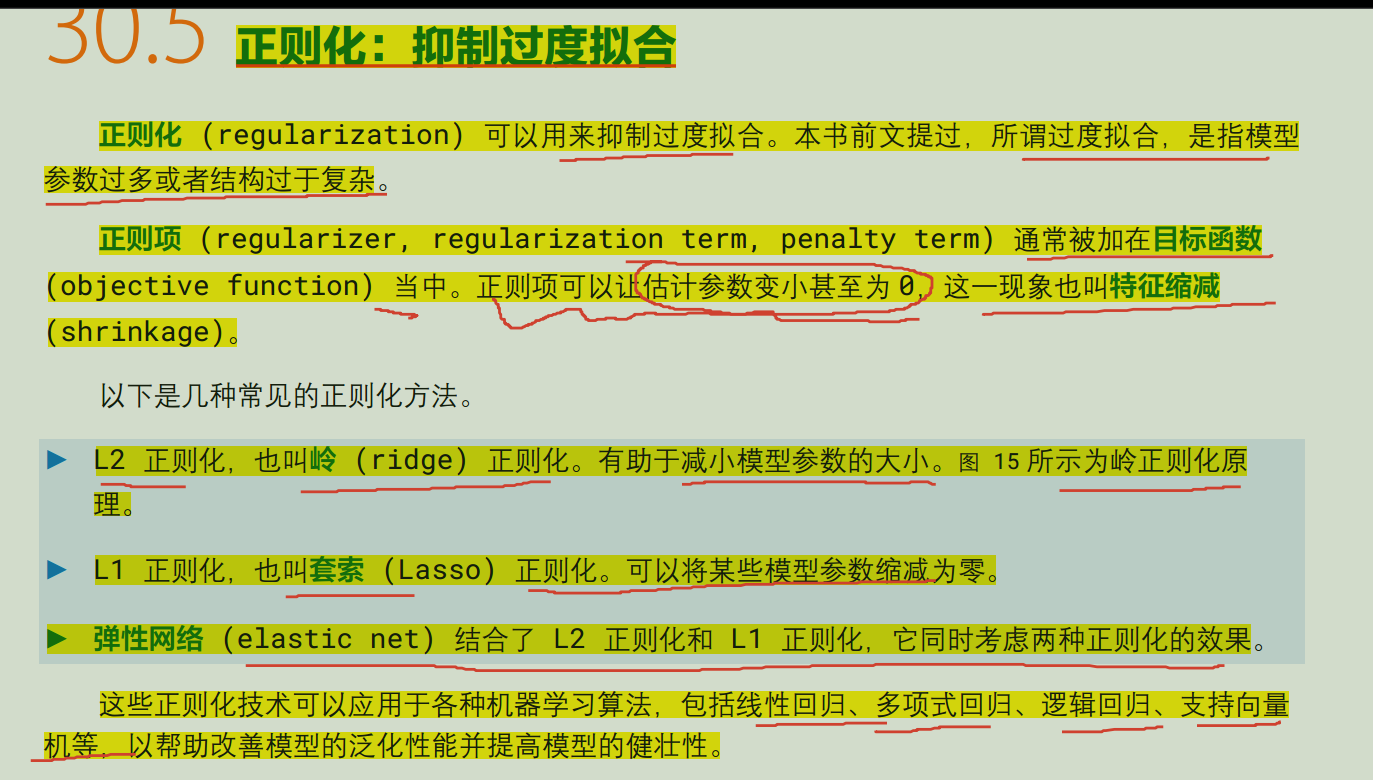

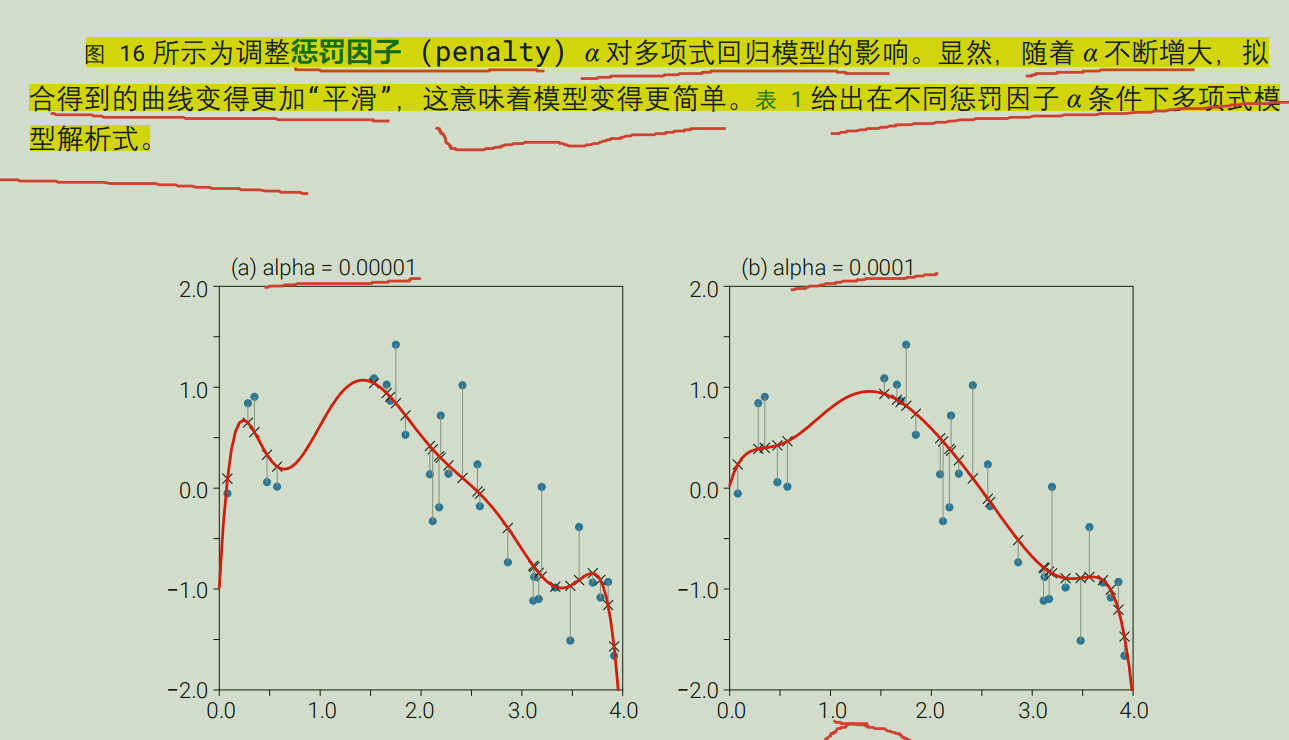

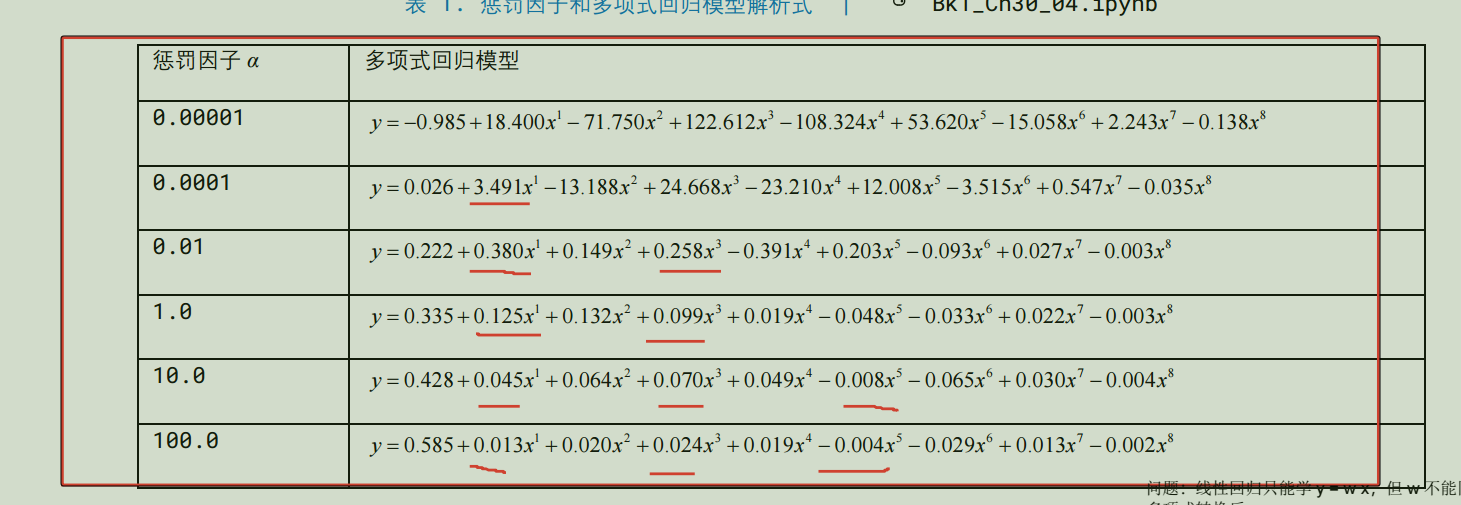

In [2]:
# 导入包
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures # 多项式
from sklearn.linear_model import Ridge # 岭回归

# 生成随机数据

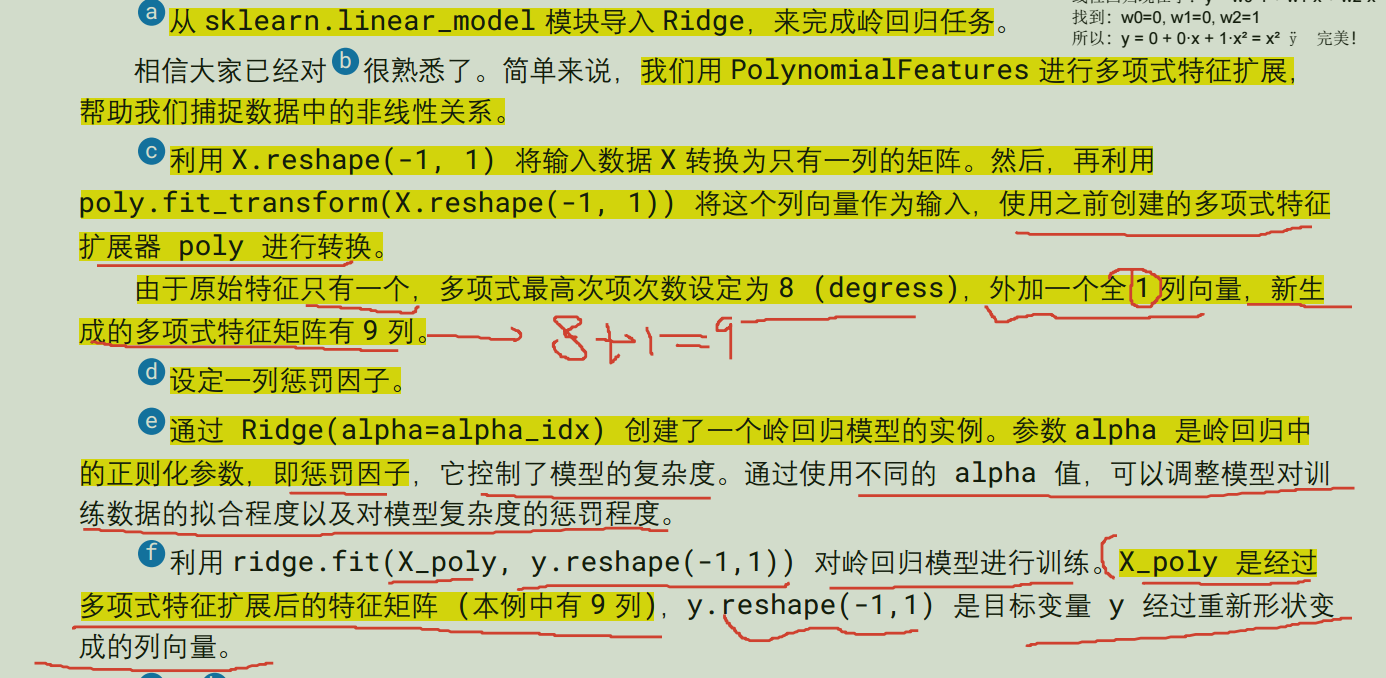

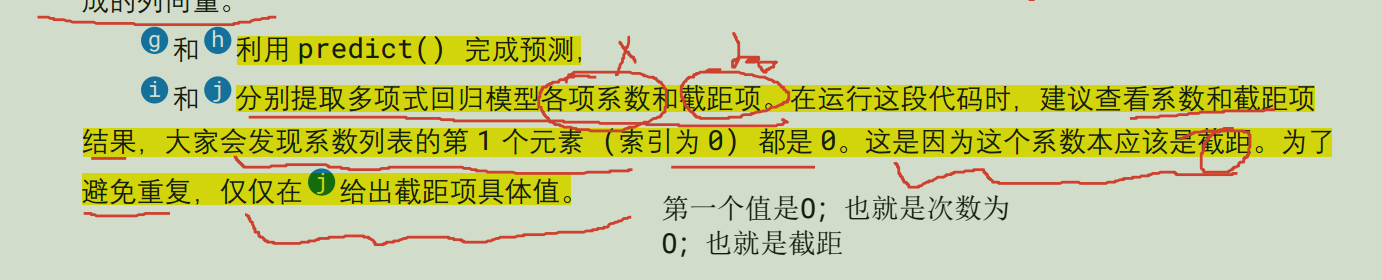

In [3]:
# 生成随机数据
np.random.seed(0) # 随机种子
num = 30  # 样本数量

In [4]:
X = np.random.uniform(0,4,num) # 生成数据
y = np.sin(0.4*np.pi * X) + 0.4 * np.random.randn(num)
data = np.column_stack([X,y]) # 组合数据

In [5]:
data

array([[ 2.19525402,  0.71943762],
       [ 2.86075747, -0.73483768],
       [ 2.4110535 ,  1.01944272],
       [ 2.17953273, -0.18983232],
       [ 1.6946192 ,  0.86623511],
       [ 2.58357645, -0.17970584],
       [ 1.75034885,  1.42187093],
       [ 3.567092  , -0.38595731],
       [ 3.85465104, -0.92938626],
       [ 1.53376608,  1.08835731],
       [ 3.16690015, -1.09845542],
       [ 2.11557968, -0.32781248],
       [ 2.27217824,  0.14322961],
       [ 3.70238655, -0.93567096],
       [ 0.28414423,  0.84164323],
       [ 0.3485172 ,  0.90504449],
       [ 0.08087359, -0.05347683],
       [ 3.33047938, -0.98514775],
       [ 3.112627  , -1.11544859],
       [ 3.48004859, -1.51101803],
       [ 3.91447337, -1.661225  ],
       [ 3.19663426,  0.0124998 ],
       [ 1.84591745,  0.52861007],
       [ 3.12211671, -0.87976984],
       [ 0.4730977 ,  0.0589865 ],
       [ 2.55968409,  0.2360652 ],
       [ 0.57341315,  0.01425562],
       [ 3.77867567, -1.08444693],
       [ 2.08739329,

In [7]:
# 生成一系列点；转为列向量
x_array = np.linspace(0,4,101).reshape(-1,1)
degree = 8 # 多项式回归次数
# 将数据扩展为9列
poly = PolynomialFeatures(degree = degree)
X_poly = poly.fit_transform(X.reshape(-1, 1))


In [8]:
poly

PolynomialFeatures(degree=8)

In [10]:
X_poly.shape

(30, 9)

In [11]:
X_poly[:3] # 第一个数据为1

array([[1.00000000e+00, 2.19525402e+00, 4.81914019e+00, 1.05792369e+01,
        2.32241122e+01, 5.09828256e+01, 1.11920253e+02, 2.45693384e+02,
        5.39359388e+02],
       [1.00000000e+00, 2.86075747e+00, 8.18393328e+00, 2.34122482e+01,
        6.69767639e+01, 1.91604277e+02, 5.48133367e+02, 1.56807662e+03,
        4.48588690e+03],
       [1.00000000e+00, 2.41105350e+00, 5.81317900e+00, 1.40158856e+01,
        3.37930501e+01, 8.14768518e+01, 1.96445049e+02, 4.73639524e+02,
        1.14197023e+03]])

In [12]:
X_poly[1,1]

np.float64(2.860757465489678)

# 绘制图像

0.0
-0.9847807991886133
[-0.9847808]
[   0.           18.39956959  -71.750137    122.61207129 -108.32392382
   53.62019336  -15.05837658    2.24327995   -0.13771658]
$y = -0.985 + 18.400x^1 -71.750x^2 + 122.612x^3 -108.324x^4 + 53.620x^5 -15.058x^6 + 2.243x^7 -0.138x^8$
0.0
0.02649488402728606
[0.02649488]
[  0.           3.49108698 -13.18849129  24.6683364  -23.20951721
  12.0079378   -3.51490395   0.54733642  -0.0352303 ]
$y = 0.026 + 3.491x^1 -13.188x^2 + 24.668x^3 -23.210x^4 + 12.008x^5 -3.515x^6 + 0.547x^7 -0.035x^8$
0.0
0.22235905481593887
[0.22235905]
[ 0.          0.380075    0.14857831  0.25847829 -0.39129835  0.20255791
 -0.09279885  0.02684631 -0.00289203]
$y = 0.222 + 0.380x^1 + 0.149x^2 + 0.258x^3 -0.391x^4 + 0.203x^5 -0.093x^6 + 0.027x^7 -0.003x^8$
0.0
0.3350837778085771
[0.33508378]
[ 0.          0.1247382   0.13189186  0.09937999  0.01922687 -0.04813805
 -0.03329875  0.0222131  -0.00296696]
$y = 0.335 + 0.125x^1 + 0.132x^2 + 0.099x^3 + 0.019x^4 -0.048x^5 -0.033x^6 + 0.0

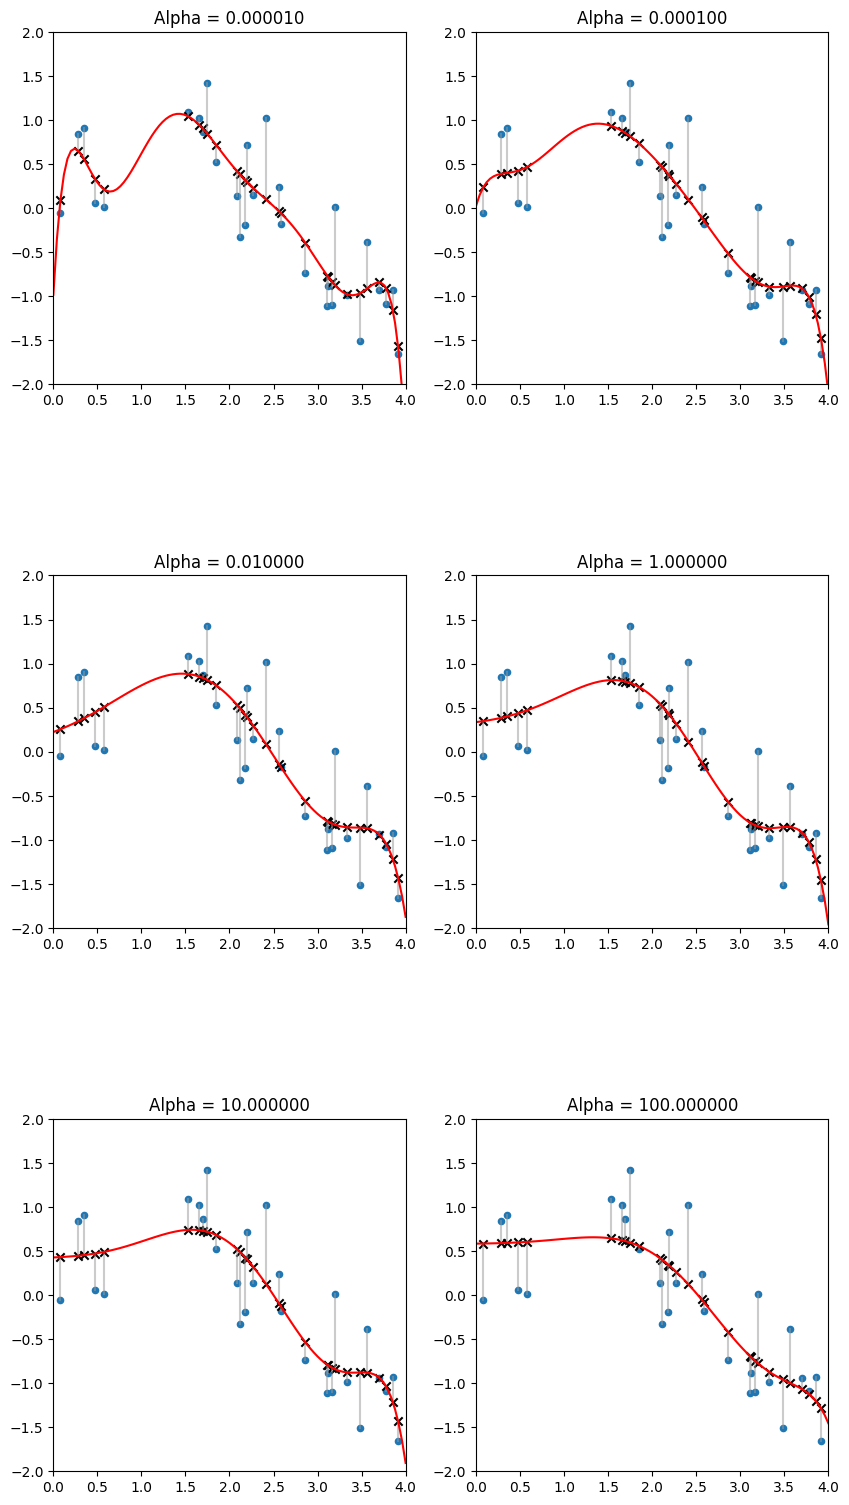

In [15]:
fig, axes = plt.subplots(3,2,figsize=(10,20))
axes = axes.flatten() # 展为一维数组
# 惩罚因子
alpha_array = [0.00001, 0.0001, 0.01, 1, 10, 100]

# 类似字典
for ax, alpha_idx in zip(axes,alpha_array):

    # 训练岭回归模型；参数为惩罚因子
    ridge = Ridge(alpha=alpha_idx)
    # 对数据进行拟合；将其y转为列向量
    ridge.fit(X_poly, y.reshape(-1,1))
    # 预测转换后的数据；x_array;一系列点
    y_array_pred = ridge.predict(poly.fit_transform(x_array))
    # 对原始数据作为参数；带入模型进行预测
    y_poly_pred  = ridge.predict(X_poly)

    # 预测数据
    data_ = np.column_stack([X,y_poly_pred])
    # 绘制散点图
    ax.scatter(X, y, s=20)
    ax.scatter(X, y_poly_pred, marker = 'x', color='k')
    # 绘制残差
    ax.plot(([i for (i,j) in data_], [i for (i,j) in data]),
            ([j for (i,j) in data_], [j for (i,j) in data]),
             c=[0.6,0.6,0.6], alpha = 0.5)

    ax.plot(x_array, y_array_pred, color='r')
    ax.set_title('Alpha = %f' % alpha_idx)

    # 提取参数
    coef = ridge.coef_[0]; # print(coef)
    print(coef)
    intercept = ridge.intercept_[0]; # print(intercept)
    print(intercept)
    print(ridge.intercept_)
    # 回归解析式
    equation = '$y = {:.3f}'.format(intercept)
    coef = ridge.coef_
    print(coef)
    for j in range(1, len(coef)):
        equation += ' + {:.3f}x^{}'.format(coef[j], j)
    equation += '$'
    equation = equation.replace("+ -", "-")
    print(equation)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(0,4); ax.set_ylim(-2,2); ax.grid(False)

# 多项式回归模型参数随惩罚因子α变化

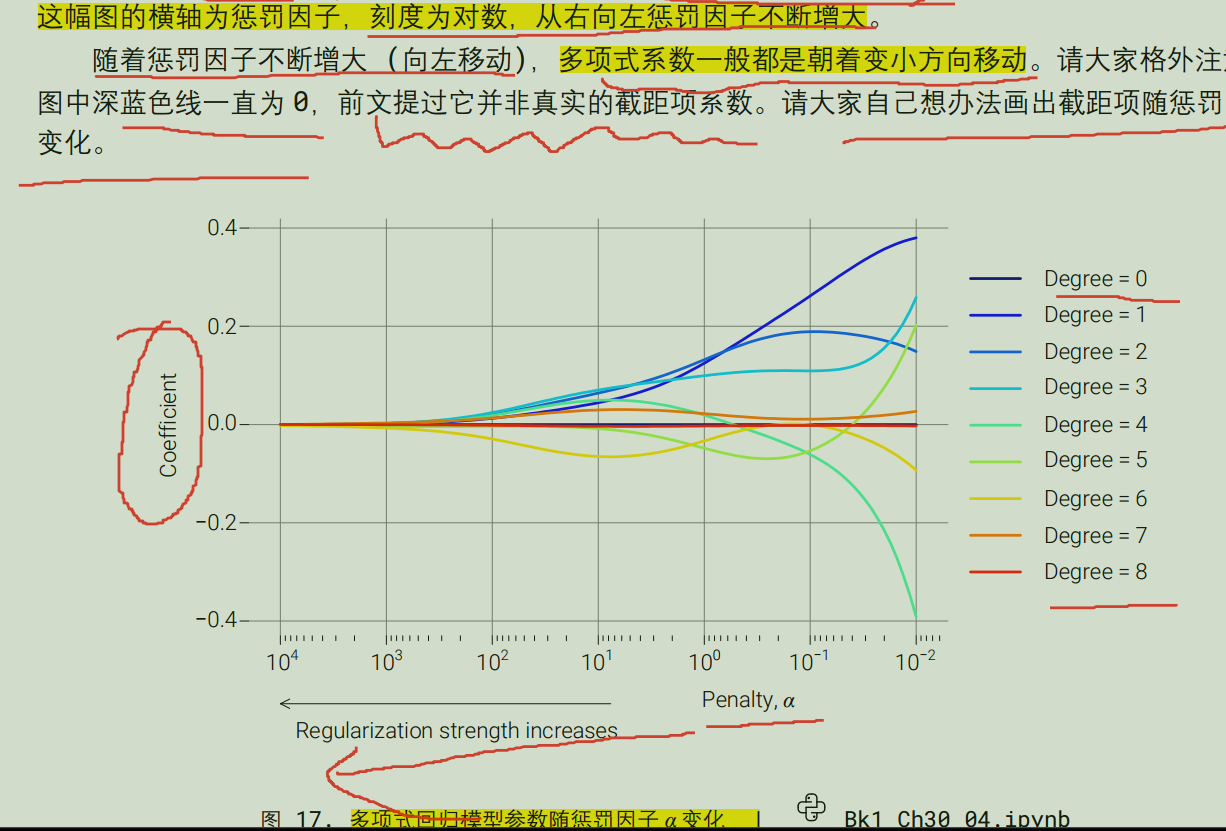

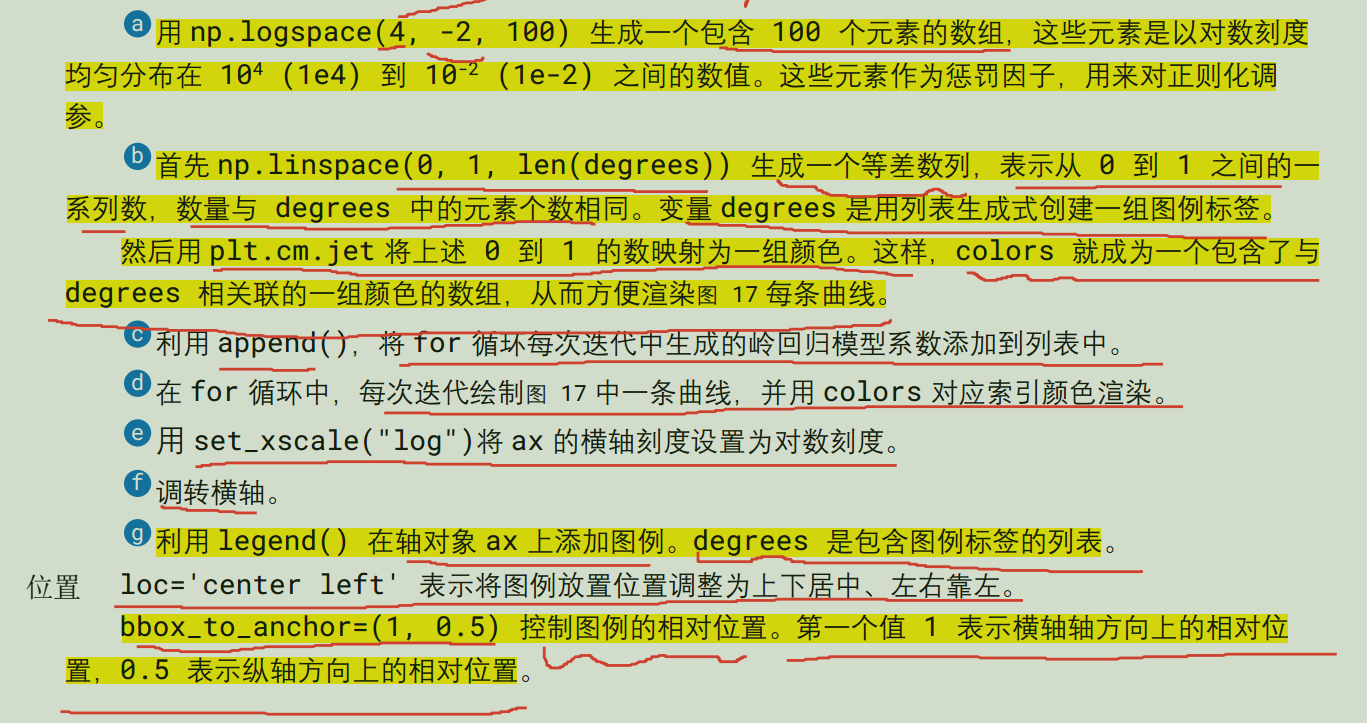

首先 np.linspace(0, 1, len(degrees)) 生成一个等差数列，表示从 0 到 1 之间的一
系列数，数量与 degrees 中的元素个数相同。变量 degrees 是用列表生成式创建一组图例标签。
然后用 plt.cm.jet 将上述 0 到 1 的数映射为一组颜色。这样，colors 就成为一个包含了与
degrees 相关联的一组颜色的数组，从而方便渲染图 17 每条曲线。


In [17]:
# 多项式回归模型参数随惩罚因子α变化
alphas = np.logspace(4, -2, 100) # 生成一系列的对数点
degrees = ['Degree = ' + str(d_i) for d_i in range(10)] # 图例数值
colors = plt.cm.jet(np.linspace(0,1,len(degrees)))

##提取系数

In [20]:
coefs_1 = []
coefs = []
# alphas：惩罚因子数组
for alpha_idx in alphas:
    ridge = Ridge(alpha=alpha_idx)
    ridge.fit(X_poly, y.reshape(-1,1)) # 进行数据拟合
    coefs.append(ridge.coef_) # 可能不对吧；ridge.coef_[0]；为0
    coefs_1.append(ridge.coef_[0])
coefs = np.array(coefs) # 转为numpy数组
coefs_1 = np.array(coefs_1)

In [22]:
coefs.shape

(100, 9)

In [24]:
coefs[:3]

array([[ 0.00000000e+00,  9.08666697e-05,  6.92023646e-05,
        -1.20864741e-04, -6.30810091e-04, -1.51112644e-03,
        -2.05697192e-03,  3.50356629e-05,  1.22693609e-04],
       [ 0.00000000e+00,  1.08606576e-04,  9.06434168e-05,
        -1.13724156e-04, -6.72832156e-04, -1.64092836e-03,
        -2.22264667e-03,  1.59927681e-04,  1.03797942e-04],
       [ 0.00000000e+00,  1.29793106e-04,  1.17326113e-04,
        -1.01175161e-04, -7.13026277e-04, -1.77791376e-03,
        -2.40267522e-03,  2.94248136e-04,  8.35263537e-05]])

In [23]:
coefs_1.shape

(100,)

In [25]:
coefs_1

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

## 绘制图像

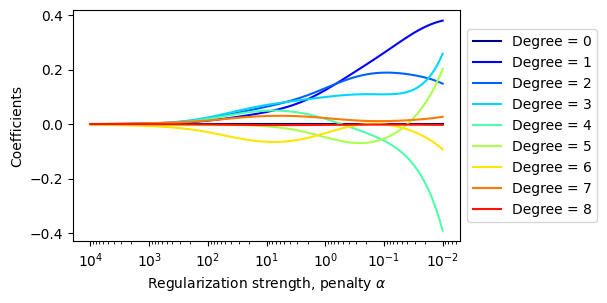

In [26]:
fig, ax = plt.subplots(figsize=(5,3))

# coefs[:,idx]；每一列的数据； olors[idx]颜色
for idx in range(9):
    ax.plot(alphas, coefs[:,idx], color = colors[idx])

#用 set_xscale("log")将 ax 的横轴刻度设置为对数刻度
ax.set_xscale("log")

# 反转；从大到小
ax.set_xlim(ax.get_xlim()[::-1]) # 调转横轴
ax.set_xlabel(r"Regularization strength, penalty $\alpha$")
ax.set_ylabel("Coefficients")

'''
利用 legend() 在轴对象 ax 上添加图例。degrees 是包含图例标签的列表。
loc='center left' 表示将图例放置位置调整为上下居中、左右靠左。
bbox_to_anchor=(1, 0.5) 控制图例的相对位置。第一个值 1 表示横轴轴方向上的相对位
置，0.5 表示纵轴方向上的相对位置。
'''

ax.legend(degrees,loc='center left', bbox_to_anchor=(1, 0.5))

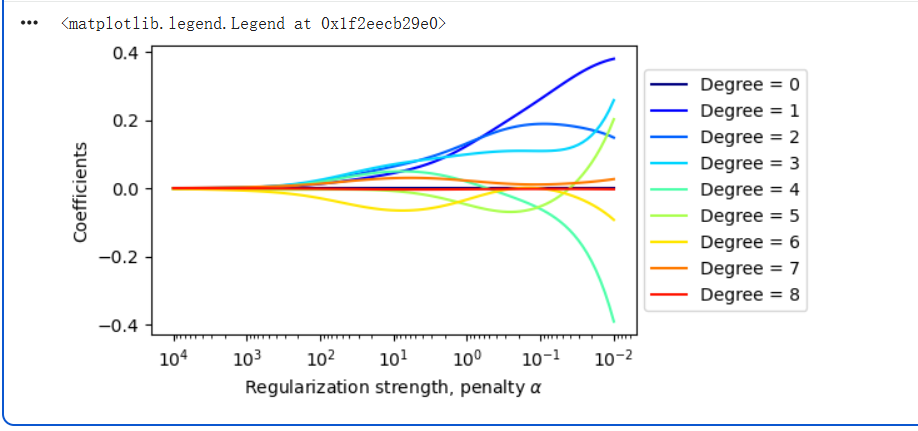